# Imputation comparison — global vs regional average

The preprocessing pipeline fills missing indicator values with
`impute_missing` (`utils/preprocessing/prepare.py`): the **global average of
all countries for that year**. This notebook compares that against
`impute_missing_regional`, which uses the **(year, sub-region) average**
instead (sub-regions from `add_region_names` / `config/iso3_to_region_name.csv`,
with a fallback to the global year average when a whole region is empty for
a year).

Both datasets are built from the raw ND-GAIN download (pre-imputation), then
the **same three models** as in `model_eval.ipynb` are backtested on each
(via [`eval_utils.py`](eval_utils.py)): per-series ARIMA, ETS, and
shared-order ARIMA. Last 5 years held out per country; MAE per
(country, indicator, model).

> Requires `data/inputs/fetch/ndgain_raw.csv` (re-download with
> `python data/inputs/fetch/fetch_ndgain.py` if missing).

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "notebooks"))
os.chdir(ROOT)  # prepare.py reads config/ files with paths relative to the repo root

import eval_utils
from eval_utils import INDICATORS, MODEL_LABELS, TEST_YEARS
from utils.preprocessing.filter import filter_indicators
from utils.preprocessing.clean import clean_data
from utils.preprocessing import prepare

pd.set_option("display.float_format", "{:.4f}".format)

IMPUTATION_COLORS = {"global": "#2a78d6", "regional": "#eb6834"}

## Build the two datasets

Same pipeline steps as `prepare_for_model`, split open so the imputation step
can be swapped: pivot → drop countries → **impute (global | regional)** →
reverse readiness indicators → sort.

In [2]:
raw = pd.read_csv(ROOT / "data" / "inputs" / "fetch" / "ndgain_raw.csv")
tidy = clean_data(filter_indicators(raw))
wide = prepare.drop_countries(prepare.pivot_indicators(tidy))

def finish(imputed):
    return prepare.sort_time_series(prepare.reverse_readiness_indicators(imputed))

df_global = finish(prepare.impute_missing(wide.copy()))
df_regional = finish(prepare.impute_missing_regional(wide.copy()))

print(f"{wide['Country'].nunique()} countries, years "
      f"{wide['Year'].min()}-{wide['Year'].max()}")

186 countries, years 1995-2023


In [3]:
indicator_cols = [c for c in INDICATORS if c in wide.columns]

missing = wide[indicator_cols].isna()
n_cells = missing.size
print(f"Missing cells before imputation: {missing.values.sum()} / {n_cells} "
      f"({missing.values.mean():.1%})")

diff = (df_global[indicator_cols] - df_regional[indicator_cols]).abs()
print(f"Cells where the two imputations differ: {(diff.values > 1e-12).sum()} "
      f"(max abs difference {np.nanmax(diff.values):.4f})\n")

summary = pd.DataFrame({
    "missing": missing.sum(),
    "missing_pct": missing.mean(),
    "mean_abs_imputation_diff": diff[missing].mean(),  # among imputed cells only
}).sort_values("missing", ascending=False)
summary.style.format({"missing_pct": "{:.1%}", "mean_abs_imputation_diff": "{:.4f}"})

Missing cells before imputation: 1943 / 64728 (3.0%)
Cells where the two imputations differ: 1827 (max abs difference 0.2737)



,missing,missing_pct,mean_abs_imputation_diff
Infrastructure,580,10.8%,0.0080
Water,464,8.6%,0.0028
Capacity,290,5.4%,0.0000
Ecosystems,174,3.2%,0.0010
Social,116,2.2%,0.0000
Sensitivity,116,2.2%,0.0000
Governance,87,1.6%,0.0000
Economic,87,1.6%,0.0000
Health,29,0.5%,0.0000
Exposure,0,0.0%,nan


## Run both backtests

Three models x two datasets — **this takes ~20-30 minutes**.

In [4]:
runs = {}
for name, data in [("global", df_global), ("regional", df_regional)]:
    print(f"=== {name} imputation ===")
    res, preds, info = eval_utils.run_backtests(data)
    res["imputation"] = name
    preds["imputation"] = name
    runs[name] = (res, preds, info)
    print(f"  failed fits: {res['error'].notna().sum()}, "
          f"ARIMA fallbacks: {info['arima_convergence_fallbacks']}")

results = pd.concat([runs[k][0] for k in runs], ignore_index=True)
preds = pd.concat([runs[k][1] for k in runs], ignore_index=True)
valid = results[results["error"].isna()]

=== global imputation ===
Per-series backtest 1/186: AFG
Per-series backtest 11/186: BDI
Per-series backtest 21/186: BLZ
Per-series backtest 31/186: CHL
Per-series backtest 41/186: CUB
Per-series backtest 51/186: EGY
Per-series backtest 61/186: GBR
Per-series backtest 71/186: GUY
Per-series backtest 81/186: ISL
Per-series backtest 91/186: KIR
Per-series backtest 101/186: LSO
Per-series backtest 111/186: MKD
Per-series backtest 121/186: MYS
Per-series backtest 131/186: PAK
Per-series backtest 141/186: QAT
Per-series backtest 151/186: SLV
Per-series backtest 161/186: SYR
Per-series backtest 171/186: TUR
Per-series backtest 181/186: VUT
Shared-order backtest: selecting orders and fitting 186 countries x 11 indicators...
  failed fits: 0, ARIMA fallbacks: 631
=== regional imputation ===
Per-series backtest 1/186: AFG
Per-series backtest 11/186: BDI
Per-series backtest 21/186: BLZ
Per-series backtest 31/186: CHL
Per-series backtest 41/186: CUB
Per-series backtest 51/186: EGY
Per-series back

## MAE — global vs regional imputation

In [5]:
overall = (
    valid.groupby(["model", "imputation"])["mae"]
    .agg(["mean", "median"])
    .unstack("imputation")
    .rename(index=MODEL_LABELS)
)
print("Overall MAE across all (country, indicator) pairs:")
overall.style.format("{:.6f}")

Overall MAE across all (country, indicator) pairs:


In [6]:
by_ind = (
    valid.groupby(["indicator", "model", "imputation"])["mae"].mean()
    .unstack(["model", "imputation"])
    .sort_index(axis=1)
)
by_ind.columns = by_ind.columns.set_names(["model", "imputation"])

def highlight_better_imputation(row):
    styles = pd.Series("", index=row.index)
    for model in row.index.get_level_values("model").unique():
        pair = row[model]
        if pair.notna().sum() == 2 and pair["global"] != pair["regional"]:
            styles[(model, pair.idxmin())] = "background-color: lightgreen"
    return styles

print("Mean MAE per indicator (green = better imputation within each model):")
by_ind.rename(columns=MODEL_LABELS, level="model").style.apply(
    highlight_better_imputation, axis=1
).format("{:.6f}", na_rep="—")

Mean MAE per indicator (green = better imputation within each model):


In [7]:
delta = (
    by_ind.stack("model", future_stack=True)
    .assign(delta=lambda d: d["regional"] - d["global"])["delta"]
    .unstack("model")
    .rename(columns=MODEL_LABELS)
)
print("MAE delta (regional - global): negative = regional imputation better")
delta.style.format("{:+.6f}", na_rep="—").map(
    lambda v: "color: #1a7a1a" if isinstance(v, float) and v < 0
    else ("color: #b03030" if isinstance(v, float) and v > 0 else "")
)

MAE delta (regional - global): negative = regional imputation better


model,ARIMA (per-series order),ARIMA (shared order),ETS (Holt)
indicator,,,
Capacity,+0.000833,+0.001277,+0.000954
Economic,+0.000627,+0.000581,+0.000213
Ecosystems,-0.000020,+0.000004,-0.000018
Exposure,+0.000000,—,+0.000000
Food,+0.000000,+0.000000,+0.000000
Governance,+0.000082,+0.000089,+0.000110
Habitat,+0.000000,+0.000000,+0.000000
Health,+0.000126,+0.000032,+0.000007
Infrastructure,+0.000226,+0.000505,+0.000631


### Per-indicator view

Paired bars per model: global vs regional MAE. Color encodes the imputation
variant, consistently across the three panels.

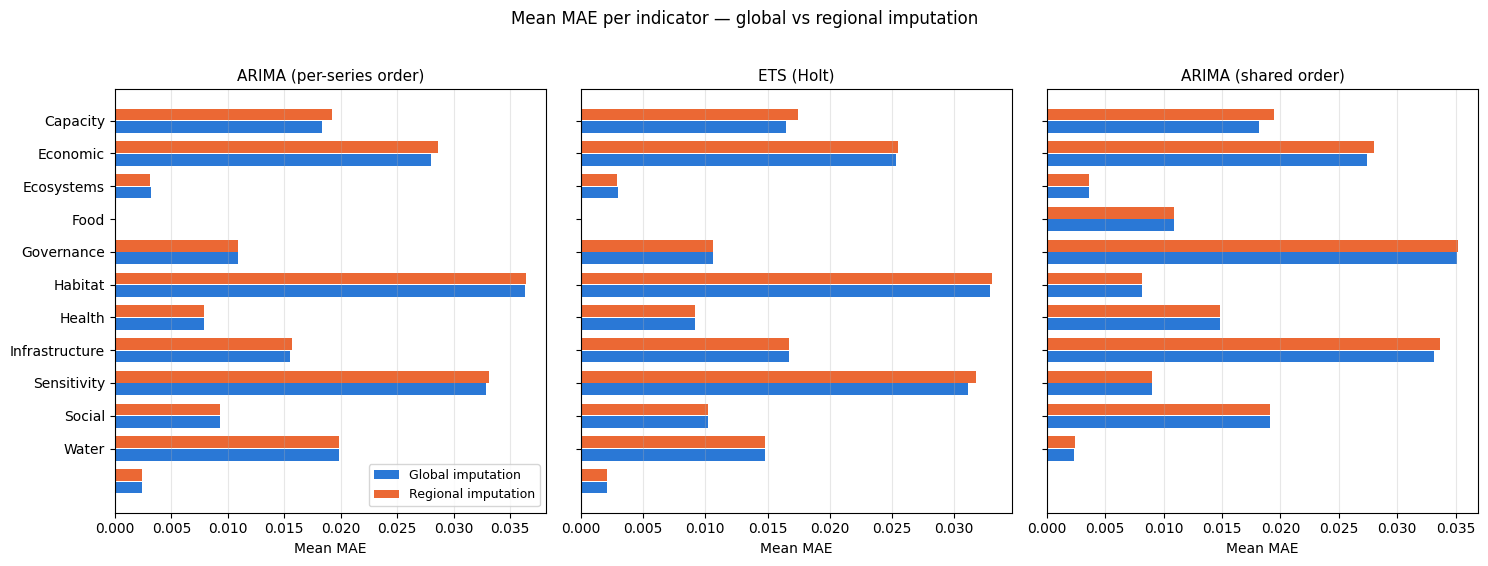

In [8]:
models = [m for m in MODEL_LABELS if m in by_ind.columns.get_level_values("model")]
fig, axes = plt.subplots(1, len(models), figsize=(15, 5.5), sharey=True)

for ax, model in zip(np.atleast_1d(axes), models):
    sub = by_ind[model].dropna()
    y = np.arange(len(sub))
    ax.barh(y + 0.19, sub["global"], height=0.36,
            color=IMPUTATION_COLORS["global"], label="Global imputation")
    ax.barh(y - 0.19, sub["regional"], height=0.36,
            color=IMPUTATION_COLORS["regional"], label="Regional imputation")
    ax.set_yticks(y, sub.index)
    ax.invert_yaxis()
    ax.set_title(MODEL_LABELS[model], fontsize=11)
    ax.set_xlabel("Mean MAE")
    ax.grid(axis="x", alpha=0.3)

np.atleast_1d(axes)[0].legend(fontsize=9, loc="lower right")
fig.suptitle("Mean MAE per indicator — global vs regional imputation", y=1.02)
plt.tight_layout()
plt.show()

## Caveat: the two runs are scored against different "actuals"

Each run is evaluated against its own dataset, so where a test-window value
was itself imputed, the target differs between the two runs — part of any MAE
gap can come from the target moving, not the model improving. The table below
recomputes MAE only on **observed** test-window values (cells that were not
missing before imputation), which isolates the effect of imputation on
*fitting* the models.

In [9]:
observed = (
    wide.melt(id_vars=["Country", "Year"], value_vars=indicator_cols,
              var_name="indicator", value_name="raw_value")
    .rename(columns={"Country": "country", "Year": "year"})
)
observed["observed"] = observed["raw_value"].notna()

merged = preds.merge(observed[["country", "year", "indicator", "observed"]],
                     on=["country", "year", "indicator"], how="left")
obs_preds = merged[merged["observed"].fillna(False)]
print(f"Observed test-window cells: {obs_preds[['country','indicator','year']].drop_duplicates().shape[0]} "
      f"of {preds[['country','indicator','year']].drop_duplicates().shape[0]}")

obs_mae = (
    obs_preds.assign(abs_err=lambda d: (d["predicted"] - d["actual"]).abs())
    .groupby(["indicator", "model", "imputation"])["abs_err"].mean()
    .unstack(["model", "imputation"])
    .sort_index(axis=1)
)
obs_mae.columns = obs_mae.columns.set_names(["model", "imputation"])
print("Mean MAE on observed test values only:")
obs_mae.rename(columns=MODEL_LABELS, level="model").style.apply(
    highlight_better_imputation, axis=1
).format("{:.6f}", na_rep="—")

Observed test-window cells: 10825 of 11160
Mean MAE on observed test values only:


In [10]:
## Caveat: so let's check what's actually behind missing values....

In [11]:
# Missingness structure per (country, indicator) series:
# a series is "complete" (no missing years), "partial" (some), or "fully missing" (all).
series_miss = (
    wide.melt(id_vars=["Country", "Year"], value_vars=indicator_cols,
              var_name="indicator", value_name="value")
    .assign(missing=lambda d: d["value"].isna())
    .groupby(["Country", "indicator"])["missing"]
    .agg(n_years="size", n_missing="sum")
    .assign(status=lambda d: np.select(
        [d["n_missing"] == 0, d["n_missing"] == d["n_years"]],
        ["complete", "fully missing"],
        default="partially missing",
    ))
)

structure = (
    series_miss.reset_index()
    .pivot_table(index="indicator", columns="status", values="n_missing",
                 aggfunc="size", fill_value=0)
    .reindex(columns=["complete", "partially missing", "fully missing"], fill_value=0)
)
structure.loc["TOTAL"] = structure.sum()
print(f"Series total: {len(series_miss)} — partially missing: "
      f"{(series_miss['status'] == 'partially missing').sum()}")
structure

Series total: 2232 — partially missing: 0


status,complete,partially missing,fully missing
indicator,,,
Capacity,176,0,10
Economic,183,0,3
Ecosystems,180,0,6
Exposure,186,0,0
Food,186,0,0
Governance,183,0,3
Habitat,186,0,0
Health,185,0,1
Infrastructure,166,0,20


In [12]:
# Matrix of the fully-missing series: one row per affected country, red = the
# country never reported that indicator (its whole series is imputed).
names = pd.read_csv(ROOT / "config" / "iso3_to_country_name.csv", sep=";").set_index("ISO3")["Name"]
regions = pd.read_csv(ROOT / "config" / "iso3_to_region_name.csv").set_index("ISO3")["sub_region"]

fully = series_miss[series_miss["status"] == "fully missing"].reset_index()

matrix = (
    fully.assign(flag=1)
    .pivot_table(index="Country", columns="indicator", values="flag", fill_value=0)
    .reindex(columns=[c for c in indicator_cols if c in fully["indicator"].unique()], fill_value=0)
)
matrix.insert(0, "Name", matrix.index.map(names))
matrix.insert(1, "Region", matrix.index.map(regions))
matrix["n_missing"] = matrix.drop(columns=["Name", "Region"]).sum(axis=1).astype(int)
matrix = matrix.sort_values(["n_missing", "Region"], ascending=[False, True])

print(f"{len(fully)} fully-missing series across {len(matrix)} countries:")
(matrix.style
 .map(lambda v: "background-color: #f4cccc" if v == 1 else "", 
      subset=[c for c in matrix.columns if c not in ("Name", "Region", "n_missing")])
 .format({c: (lambda v: "✗" if v == 1 else "") 
          for c in matrix.columns if c not in ("Name", "Region", "n_missing")}))



67 fully-missing series across 39 countries:


indicator,Name,Region,Capacity,Economic,Ecosystems,Governance,Health,Infrastructure,Sensitivity,Social,Water,n_missing
Country,,,,,,,,,,,,
DMA,Dominica,Latin America and the Caribbean,✗,,,,,✗,,✗,✗,4
KNA,Saint Kitts and Nevis,Latin America and the Caribbean,✗,,✗,,,✗,,,✗,4
FSM,"Micronesia, Federated States of",Micronesia,✗,,✗,,,,✗,,✗,4
KIR,Kiribati,Micronesia,,,✗,,,,✗,✗,✗,4
MHL,Marshall Islands,Micronesia,✗,,✗,,,,✗,,✗,4
PLW,Palau,Micronesia,✗,,✗,,,,✗,,✗,4
BHS,Bahamas,Latin America and the Caribbean,✗,,,,,✗,,,✗,3
VCT,Saint Vincent and the Grenadines,Latin America and the Caribbean,✗,,✗,,,,,,✗,3
TLS,Timor-Leste,South-eastern Asia,✗,,,✗,,✗,,,,3
